Importing libraries

In [ ]:
# Library for Data Manipulation
import numpy as np
import pandas as pd

# Library for Ignoring the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

Loading and Understanding dataset

In [ ]:
data = pd.read_csv(r'/content/CloudWatch_Traffic_Web_Attack.csv')

In [ ]:
# Basic info
print(f"Data Shape: {data.shape}")
print("Columns:", list(data.columns))

# Show head and tail
print("First 5 rows:\n", data.head())
print("Last 5 rows:\n", data.tail())

Data Shape: (282, 16)
Columns: ['bytes_in', 'bytes_out', 'creation_time', 'end_time', 'src_ip', 'src_ip_country_code', 'protocol', 'response.code', 'dst_port', 'dst_ip', 'rule_names', 'observation_name', 'source.meta', 'source.name', 'time', 'detection_types']
First 5 rows:
    bytes_in  bytes_out         creation_time              end_time  \
0      5602      12990  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
1     30912      18186  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
2     28506      13468  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
3     30546      14278  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
4      6526      13892  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   

            src_ip src_ip_country_code protocol  response.code  dst_port  \
0   147.161.161.82                  AE    HTTPS            200       443   
1     165.225.33.6                  US    HTTPS            200       443   
2  165.225.212.255                  CA    HTTPS            200       443   

In [ ]:
# Data info and null values
print("\nData Types & Non-Null Counts:")
print(data.info())

print("\nMissing Values:\n", data.isnull().sum())


Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 n

Data Preprocessing

In [ ]:
# Drop duplicates if any
initial_shape = data.shape
data.drop_duplicates(inplace=True)
if data.shape != initial_shape:
    print(f"Removed {initial_shape[0] - data.shape[0]} duplicate rows.")

In [ ]:
#Conversion of variables to datetime

data['creation_time'] = pd.to_datetime(data['creation_time'])
data['end_time'] = pd.to_datetime(data['end_time'])
data['time'] = pd.to_datetime(data['time'])


In [ ]:
#Session duration in seconds
data['duration'] = (data['end_time'] - data['creation_time']).dt.total_seconds()

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
categorical_cols = ['protocol', 'src_ip_country_code', 'rule_names', 'observation_name',
                    'source.meta', 'source.name', 'detection_types']
for col in categorical_cols:
    data[col] = data[col].astype(str)  # Ensure categorical data is string
    data[col] = LabelEncoder().fit_transform(data[col])

In [ ]:
data['bytes_total'] = data['bytes_in'] + data['bytes_out']

Data Visualization

In [ ]:
# Export to CSV for Tableau
data.to_csv("tableau_cyber_threats.csv", index=False)

# Optional: Display a message when done
print("CSV file 'tableau_cyber_threats.csv' created successfully.")

CSV file 'tableau_cyber_threats.csv' created successfully.


Model Selection And Training

1. Isolation Forest

In [ ]:
#importing all necessary libraries


from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Selecting only the relevant features
features = ['bytes_in', 'bytes_out', 'src_ip_country_code', 'protocol', 'response.code', 'dst_port']
X = data[features]

In [ ]:
#Standardize the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
iso_forest = IsolationForest( contamination=0.1, random_state=42)
data['anomaly'] = iso_forest.fit_predict(X_scaled)

In [ ]:
#Filter anomalies
anomalies = data[data['anomaly'] == -1]
print("Detected Anomalies:")
print(anomalies)

Detected Anomalies:
     bytes_in  bytes_out             creation_time                  end_time  \
15    1968903      38773 2024-04-25 23:10:00+00:00 2024-04-25 23:20:00+00:00   
36    4190330     283456 2024-04-25 23:30:00+00:00 2024-04-25 23:40:00+00:00   
43    2015975      79990 2024-04-25 23:40:00+00:00 2024-04-25 23:50:00+00:00   
47    4758826     289956 2024-04-25 23:40:00+00:00 2024-04-25 23:50:00+00:00   
87    1215594      64362 2024-04-26 00:30:00+00:00 2024-04-26 00:40:00+00:00   
116   4827283     306181 2024-04-26 01:00:00+00:00 2024-04-26 01:10:00+00:00   
132   1889834      34306 2024-04-26 01:20:00+00:00 2024-04-26 01:30:00+00:00   
142   1253276      46666 2024-04-26 01:30:00+00:00 2024-04-26 01:40:00+00:00   
146   4808787     301495 2024-04-26 01:30:00+00:00 2024-04-26 01:40:00+00:00   
153   4869181     301752 2024-04-26 01:40:00+00:00 2024-04-26 01:50:00+00:00   
161   4755578     292284 2024-04-26 01:50:00+00:00 2024-04-26 02:00:00+00:00   
169  18201558    117

In [ ]:
# Count anomalies (-1) and normal points (1)
anomaly_counts = data['anomaly'].value_counts()
print(anomaly_counts)

# Percentage of anomalies
anomaly_percentage = (anomaly_counts[-1] / len(data)) * 100
print(f"Percentage of anomalies: {anomaly_percentage:.2f}%")

anomaly
 1    254
-1     28
Name: count, dtype: int64
Percentage of anomalies: 9.93%




*   Hyperparameter Tuning



In [ ]:
#Grid Search
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# Define hyperparameter values
n_estimators = [50, 75, 100]
max_samples = [128, 200, 256]
contamination = [0.05, 0.07, 0.1]

best_model = None
best_score = float('-inf')

for n in n_estimators:
    for ms in max_samples:
        for c in contamination:
            model = IsolationForest(n_estimators=n, max_samples=ms, contamination=c, random_state=42)
            model.fit(X_scaled)
            preds = model.predict(X_scaled)


            preds = [1 if p == -1 else 0 for p in preds]

            # Calculate anomaly ratio
            anomaly_ratio = sum(preds) / len(preds)

            # Choose model where detected anomalies are close to expected (5-10%)
            if 0.05 <= anomaly_ratio <= 0.1:
                best_model = model
                best_score = anomaly_ratio

print(f"Best Model: {best_model}, Anomaly Ratio: {best_score}")

Best Model: IsolationForest(contamination=0.1, max_samples=256, random_state=42), Anomaly Ratio: 0.09929078014184398


In [ ]:
model = IsolationForest(contamination=0.1, max_samples=256, random_state=42)
model.fit(X_scaled)

IsolationForest(contamination=0.1, max_samples=256, random_state=42)

In [ ]:
predictions = model.predict(X_scaled )

In [ ]:
data['anomaly'] = predictions

In [ ]:
# Filter anomalies
anomalies = data[data['anomaly'] == -1]
print("Detected Anomalies:")
print(anomalies)

Detected Anomalies:
     bytes_in  bytes_out             creation_time                  end_time  \
15    1968903      38773 2024-04-25 23:10:00+00:00 2024-04-25 23:20:00+00:00   
36    4190330     283456 2024-04-25 23:30:00+00:00 2024-04-25 23:40:00+00:00   
43    2015975      79990 2024-04-25 23:40:00+00:00 2024-04-25 23:50:00+00:00   
47    4758826     289956 2024-04-25 23:40:00+00:00 2024-04-25 23:50:00+00:00   
87    1215594      64362 2024-04-26 00:30:00+00:00 2024-04-26 00:40:00+00:00   
116   4827283     306181 2024-04-26 01:00:00+00:00 2024-04-26 01:10:00+00:00   
132   1889834      34306 2024-04-26 01:20:00+00:00 2024-04-26 01:30:00+00:00   
142   1253276      46666 2024-04-26 01:30:00+00:00 2024-04-26 01:40:00+00:00   
146   4808787     301495 2024-04-26 01:30:00+00:00 2024-04-26 01:40:00+00:00   
153   4869181     301752 2024-04-26 01:40:00+00:00 2024-04-26 01:50:00+00:00   
161   4755578     292284 2024-04-26 01:50:00+00:00 2024-04-26 02:00:00+00:00   
169  18201558    117

In [ ]:
#Count anomalies (-1) and normal points (1)
anomaly_counts = data['anomaly'].value_counts()
print(anomaly_counts)

# Percentage of anomalies
anomaly_percentage = (anomaly_counts[-1] / len(data)) * 100
print(f"Percentage of anomalies: {anomaly_percentage:.2f}%")

anomaly
 1    254
-1     28
Name: count, dtype: int64
Percentage of anomalies: 9.93%


In [ ]:
anomaly_ratio = sum(data['anomaly'] == -1) / len(data)
print(f"Anomaly Detection Rate: {anomaly_ratio * 100:.2f}%")

Anomaly Detection Rate: 9.93%


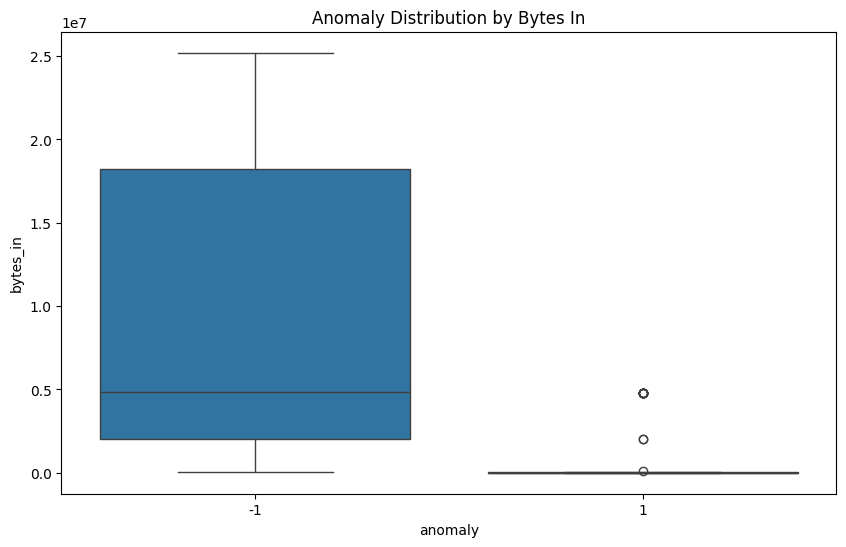

In [ ]:
#Anomaly distribution with respect to bytes in
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x=data['anomaly'], y= data['bytes_in'])
plt.title("Anomaly Distribution by Bytes In")
plt.show()

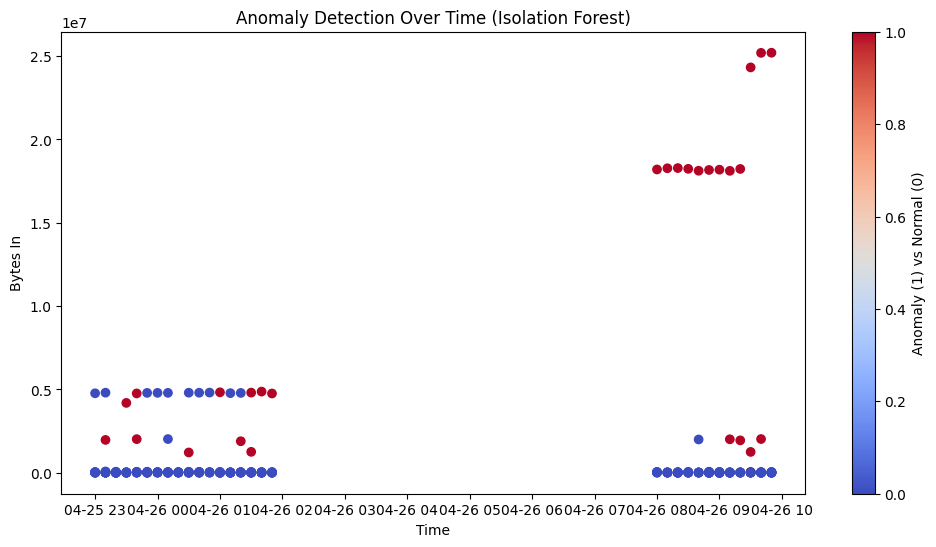

In [ ]:
#Cluster Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Convert anomaly labels
data['anomaly_binary'] = data['anomaly'].apply(lambda x: 1 if x == -1 else 0)

#Scatter Plot: Anomalies Over Time
plt.figure(figsize=(12,6))
plt.scatter(data['creation_time'], data['bytes_in'], c=data['anomaly_binary'], cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Bytes In")
plt.title("Anomaly Detection Over Time (Isolation Forest)")
plt.colorbar(label="Anomaly (1) vs Normal (0)")
plt.show()

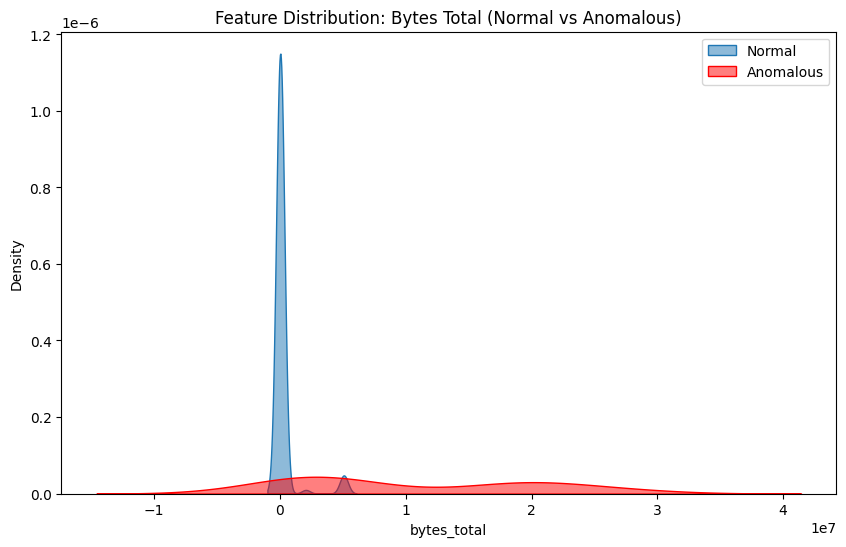

In [ ]:
#KDE Plot: Feature Distribution for Normal vs Anomalous Data
plt.figure(figsize=(10,6))
sns.kdeplot(data[data['anomaly_binary'] == 0]['bytes_total'], label="Normal", fill=True, alpha=0.5)
sns.kdeplot(data[data['anomaly_binary'] == 1]['bytes_total'], label="Anomalous", fill=True, alpha=0.5, color='red')
plt.legend()
plt.title("Feature Distribution: Bytes Total (Normal vs Anomalous)")
plt.show()

2. DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
data['anomaly_dbscan'] = dbscan.fit_predict(X_scaled)

In [ ]:
anomalies_dbscan = data[data['anomaly_dbscan'] == -1]
print(f"Total Detected Anomalies (DBSCAN): {len(anomalies_dbscan)}")

print("\n")
print("Detected Anomalies (DBSCAN):")
print(anomalies_dbscan)

Total Detected Anomalies (DBSCAN): 3


Detected Anomalies (DBSCAN):
     bytes_in  bytes_out             creation_time                  end_time  \
257  24326941    1529035 2024-04-26 09:30:00+00:00 2024-04-26 09:40:00+00:00   
267  25199191    1557598 2024-04-26 09:40:00+00:00 2024-04-26 09:50:00+00:00   
279  25207794    1561220 2024-04-26 09:50:00+00:00 2024-04-26 10:00:00+00:00   

            src_ip  src_ip_country_code  protocol  response.code  dst_port  \
257  155.91.45.242                    6         0            200       443   
267  155.91.45.242                    6         0            200       443   
279  155.91.45.242                    6         0            200       443   

           dst_ip  ...  observation_name  source.meta  source.name  \
257  10.138.69.97  ...                 0            0            0   
267  10.138.69.97  ...                 0            0            0   
279  10.138.69.97  ...                 0            0            0   

                 



*   Hyperparameter Tuning



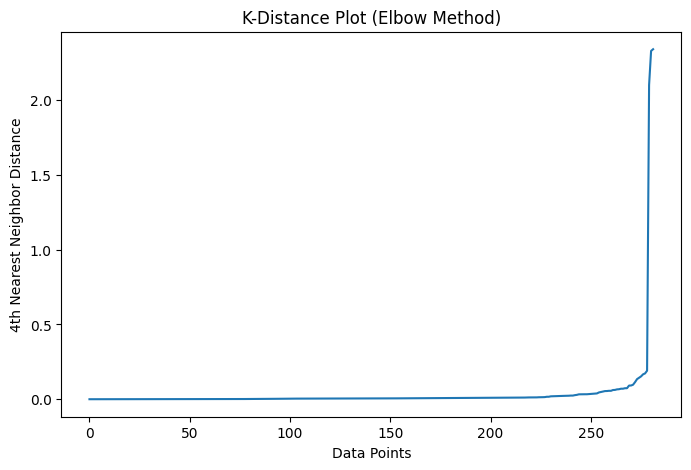

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Fit nearest neighbors model
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the distances for visualization
sorted_distances = np.sort(distances[:, 4])  # 4th neighbor distance
plt.figure(figsize=(8,5))
plt.plot(sorted_distances)
plt.xlabel("Data Points")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("K-Distance Plot (Elbow Method)")
plt.show()

In [ ]:
import numpy as np
min_samples = int(np.log(len(X_scaled)))
print("Optimal min_samples:", min_samples)

Optimal min_samples: 5


In [ ]:
#Running the DBSCAN with Tuned Parameters

from sklearn.cluster import DBSCAN

optimal_eps = 1.5  # Set based on K-distance plot
optimal_min_samples = int(np.log(len(X_scaled)))

dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
data['anomaly_dbscan'] = dbscan.fit_predict(X_scaled)

# Count detected anomalies (-1 indicates anomalies)
print("Total Anomalies Detected by DBSCAN:", (data['anomaly_dbscan'] == -1).sum())

Total Anomalies Detected by DBSCAN: 3


In [ ]:
#Anomaly Detection Rate

anomaly_count = (data['anomaly_dbscan'] == -1).sum()
total_points = len(data)
anomaly_percentage = (anomaly_count / total_points) * 100

print(f"Total Anomalies Detected by DBSCAN: {anomaly_count} ({anomaly_percentage:.2f}% of data)")

Total Anomalies Detected by DBSCAN: 3 (1.06% of data)


In [ ]:
#Cluster Analysis

import numpy as np
unique_clusters, counts = np.unique(data['anomaly_dbscan'], return_counts=True)
for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count} data points")

Cluster -1: 3 data points
Cluster 0: 270 data points
Cluster 1: 9 data points


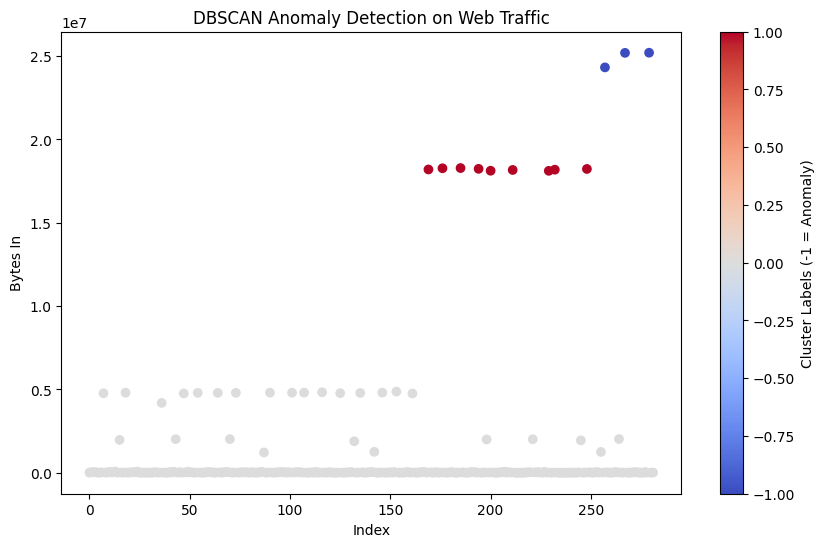

In [ ]:
#Visualizing the clusters

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(data.index, data['bytes_in'], c=data['anomaly_dbscan'], cmap='coolwarm', marker='o')
plt.xlabel("Index")
plt.ylabel("Bytes In")
plt.title("DBSCAN Anomaly Detection on Web Traffic")
plt.colorbar(label="Cluster Labels (-1 = Anomaly)")
plt.show()